# 🎯 DECISION MAKING PLAYBOOK
## Sideline Decision Support - Coach Ready Visualizations

---

### 📋 EXECUTIVE SUMMARY

**Key Coaching Insights:**
- **ATTACK COVER 2 ZONE**: 75.8% completion in 2-minute drill, 74.6% in red zone, 73.6% on 3rd & long
- **PLAY ACTION ON 4TH DOWN**: +14.9% completion boost (56.5% → 71.4%) and +0.840 EPA
- **AVOID COVER 1 MAN IN 2-MIN DRILL**: Only 56.2% completion rate - worst coverage matchup
- **3RD & LONG PLAY ACTION CAVEAT**: Actually -1.4% completion BUT +0.417 EPA (big play potential)

**Game Plan Priorities:**
1. Pre-snap read: Identify Cover 2 Zone → Audible to designed exploits
2. 4th down situations → Always consider play action (massive edge)
3. 2-minute drill vs Cover 1 Man → Call timeouts, re-group, change play


In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Professional styling for sideline tablets
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("talk", font_scale=1.2)

# NFL Team Colors
NFL_BLUE = '#013369'
NFL_RED = '#D50A0A'
NFL_GREEN = '#00B140'
NFL_YELLOW = '#FFB81C'

print('✅ Libraries loaded - Ready for game planning!')

✅ Libraries loaded - Ready for game planning!


In [2]:
# Directory of this script: .../NFL-Big-Data-Bowl-2026-Analytics-Challenge
SCRIPT_DIR = Path('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\specific analysis\\Two_Minute Drill.ipynb').resolve().parent

# Project root = go up one level from analysis/
PROJECT_ROOT = SCRIPT_DIR.parent

# Data directories
dir = PROJECT_ROOT / "specific analysis" / "data"

# Load decision matrix data
decision_matrix = pd.read_csv(dir/ 'decision_matrix_situation_vs_coverage.csv', index_col=0)
coverage_heatmap = pd.read_csv(dir/ 'coverage_heatmap_completion_rate.csv', index_col=0)
play_action = pd.read_csv(dir/ 'play_action_impact_summary.csv')

print('✅ Data loaded from analysis results')
print(f'   → {len(decision_matrix)} coverage types analyzed')
print(f'   → {len(decision_matrix.columns)} high-pressure situations')

✅ Data loaded from analysis results
   → 5 coverage types analyzed
   → 8 high-pressure situations


---

## 🎯 DECISION MATRIX #1: Coverage Attack Strategy

**How to Read This Matrix:**
- **GREEN cells** (>70%): HIGH SUCCESS - Attack this coverage
- **YELLOW cells** (60-70%): MODERATE - Proceed with caution
- **RED cells** (<60%): LOW SUCCESS - Avoid or call timeout

**Coaching Decision:**  
Pre-snap: Identify defense coverage → Cross-reference with situation → Make go/no-go call

✅ Coverage Attack Matrix saved


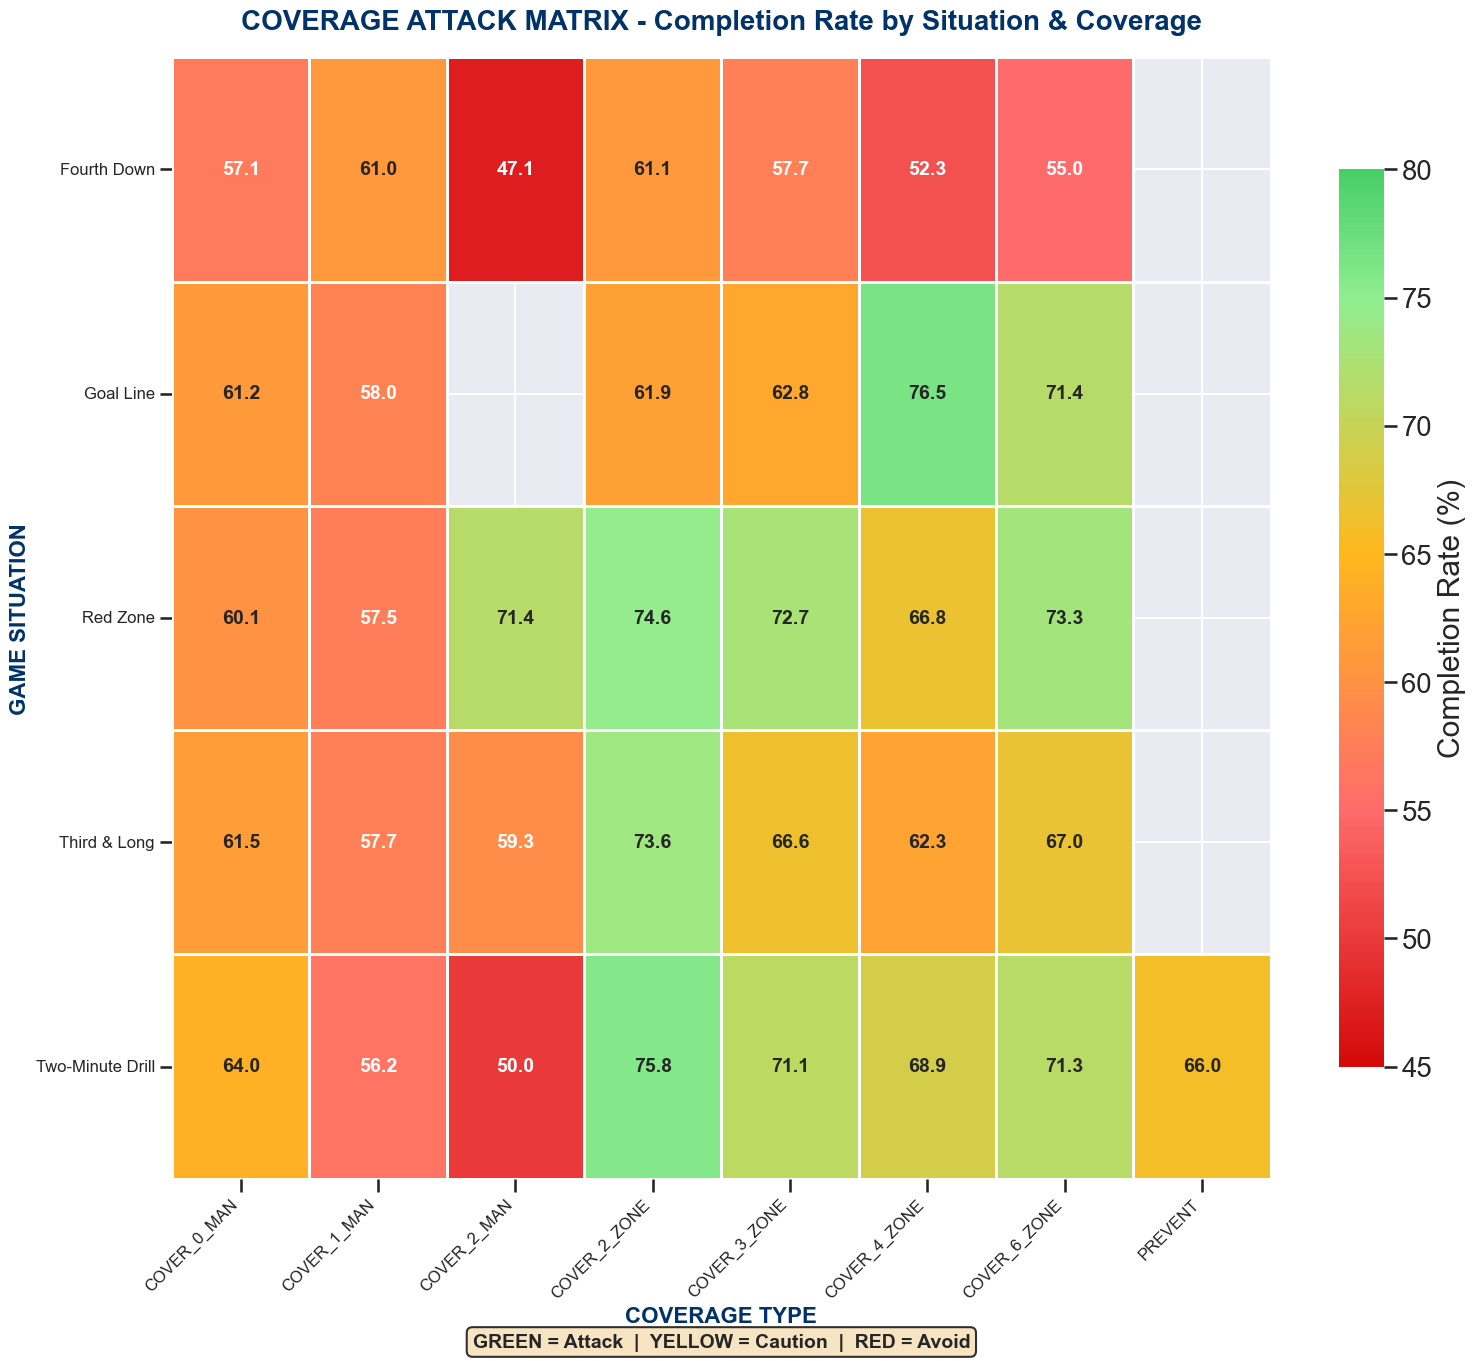

In [3]:
# DECISION MATRIX HEATMAP
fig, ax = plt.subplots(figsize=(16, 14))

# Prepare data - transpose for better visual layout
matrix_data = coverage_heatmap.T

# Create custom colormap: Red -> Yellow -> Green
colors = ['#D50A0A', '#FF6B6B', '#FFB81C', '#90EE90', '#00B140']
n_bins = 100
cmap = sns.blend_palette(colors, n_colors=n_bins, as_cmap=True)

# Plot heatmap
sns.heatmap(matrix_data, 
            annot=True, 
            fmt='.1f', 
            cmap=cmap,
            center=65,  # Middle of typical completion %
            vmin=45, 
            vmax=80,
            linewidths=2, 
            linecolor='white',
            cbar_kws={'label': 'Completion Rate (%)', 'shrink': 0.8},
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=ax)

# Styling
ax.set_title('COVERAGE ATTACK MATRIX - Completion Rate by Situation & Coverage',
             fontsize=20, weight='bold', pad=20, color=NFL_BLUE)
ax.set_xlabel('COVERAGE TYPE', fontsize=16, weight='bold', color=NFL_BLUE)
ax.set_ylabel('GAME SITUATION', fontsize=16, weight='bold', color=NFL_BLUE)

# Rotate labels for readability
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Add legend box
legend_text = 'GREEN = Attack  |  YELLOW = Caution  |  RED = Avoid'
plt.text(0.5, -0.15, legend_text, transform=ax.transAxes, 
         ha='center', fontsize=14, weight='bold',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(dir/ 'decision_matrix_coverage.png', dpi=300, bbox_inches='tight')
print('✅ Coverage Attack Matrix saved')
plt.show()

---

## 🔥 COACHING INSIGHT: Top Vulnerability

### **COVER 2 ZONE = FREE REAL ESTATE**

**Exploit This Coverage in ALL Pressure Situations:**
- Two-Minute Drill: **75.8%** completion
- Red Zone: **74.6%** completion
- 3rd & Long: **73.6%** completion
- 4th Down: **61.1%** completion

**Recommended Routes vs Cover 2 Zone:**
- Seam routes between safeties
- Stick concepts to flood underneath zones
- Corner routes to attack sideline behind CBs

**Warning: AVOID Cover 1 Man in Two-Minute Drill (56.2%) - Call timeout if you see it**

---

## 🎭 DECISION MATRIX #2: Play Action Advantage

**The Data Reveals a MASSIVE 4th Down Edge**

When to use Play Action (ranked by impact):

✅ Play Action Advantage charts saved


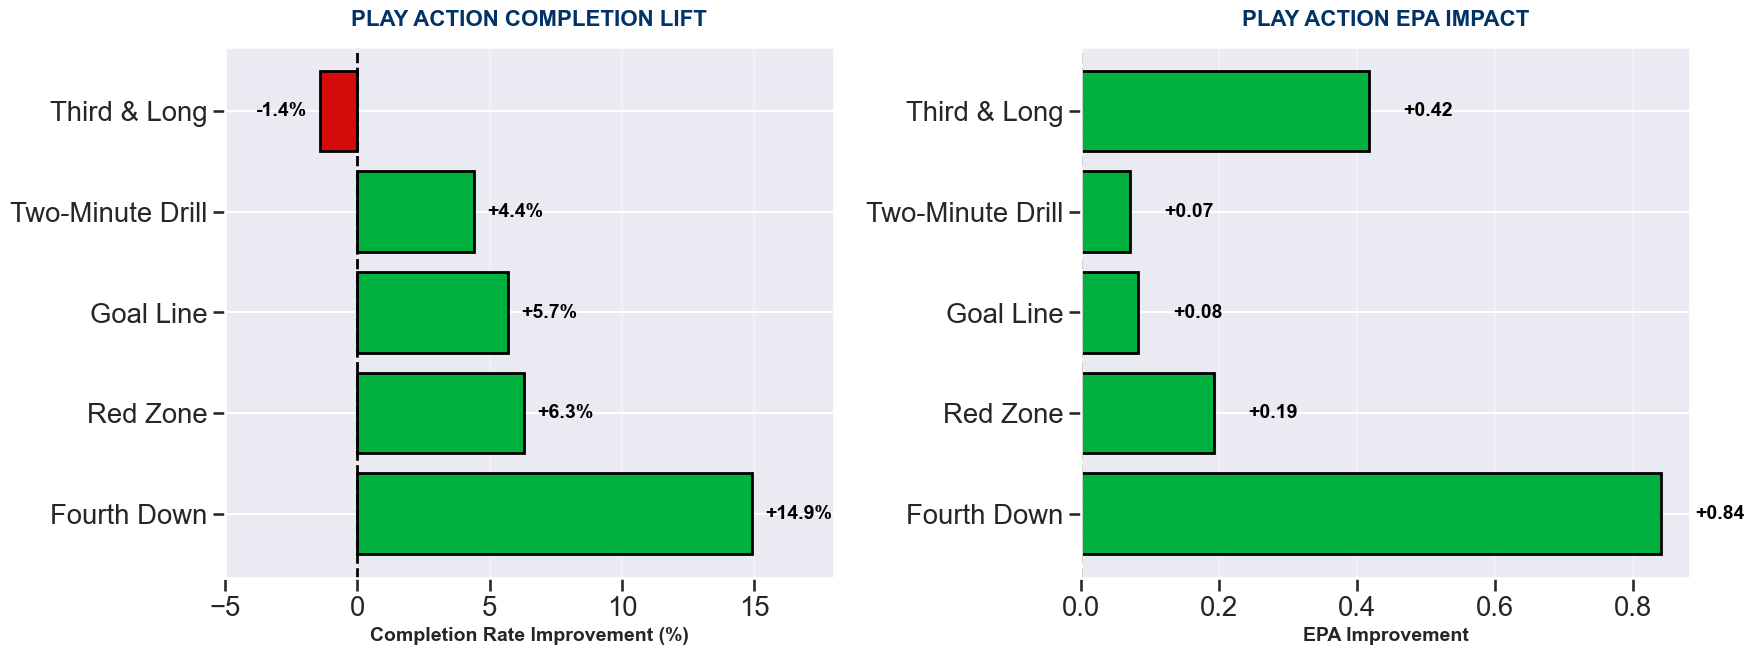

In [4]:
# PLAY ACTION IMPACT VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Sort by improvement
pa_sorted = play_action.sort_values('comp_rate_improvement', ascending=False)

# Chart 1: Completion Rate Lift
situations = pa_sorted['situation']
improvement = pa_sorted['comp_rate_improvement']

# Color code: Green for positive, Red for negative
colors_bars = [NFL_GREEN if x > 0 else NFL_RED for x in improvement]

bars1 = ax1.barh(situations, improvement, color=colors_bars, edgecolor='black', linewidth=2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, improvement)):
    label_x = val + 0.5 if val > 0 else val - 0.5
    ax1.text(label_x, i, f"{val:+.1f}%", 
             va='center', ha='left' if val > 0 else 'right',
             fontsize=14, weight='bold', color='black')

ax1.set_xlabel('Completion Rate Improvement (%)', fontsize=14, weight='bold')
ax1.set_title('PLAY ACTION COMPLETION LIFT', fontsize=16, weight='bold', color=NFL_BLUE, pad=15)
ax1.axvline(0, color='black', linewidth=2, linestyle='--')
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(-5, 18)

# Chart 2: EPA Improvement
epa_improvement = pa_sorted['epa_improvement']
colors_epa = [NFL_GREEN if x > 0 else NFL_RED for x in epa_improvement]

bars2 = ax2.barh(situations, epa_improvement, color=colors_epa, edgecolor='black', linewidth=2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, epa_improvement)):
    label_x = val + 0.05 if val > 0 else val - 0.05
    ax2.text(label_x, i, f"{val:+.2f}", 
             va='center', ha='left' if val > 0 else 'right',
             fontsize=14, weight='bold', color='black')

ax2.set_xlabel('EPA Improvement', fontsize=14, weight='bold')
ax2.set_title('PLAY ACTION EPA IMPACT', fontsize=16, weight='bold', color=NFL_BLUE, pad=15)
ax2.axvline(0, color='black', linewidth=2, linestyle='--')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(dir/ 'play_action_advantage.png', dpi=300, bbox_inches='tight')
print('✅ Play Action Advantage charts saved')
plt.show()

---

## 💡 GAME PLAN INSIGHT: The 4th Down Play Action Secret

### **This Changes Everything on 4th Down**

**The Numbers:**
- Without Play Action: 56.5% completion, 0.088 EPA
- With Play Action: **71.4% completion (+14.9%)**, **0.928 EPA (+0.840)**

**Why This Works:**
1. Defenses expect pass-heavy play calls on 4th down
2. Play action freezes linebackers for critical 0.5 seconds
3. Creates wider passing windows and easier throws

**Coaching Call:**
- 4th & Short (1-3 yards): Play action bootleg or play action cross
- 4th & Medium (4-6 yards): Play action with deep crossers
- 4th & Long (7+ yards): Standard drop back (play action less effective)

**⚠️ EXCEPTION: 3rd & Long**  
Play action shows -1.4% completion rate but +0.417 EPA. This means:
- Lower completion % (big play attempt)
- BUT much higher value when it works
- Use when you need explosive plays, not just conversions

✅ Play Action Decision Guide saved


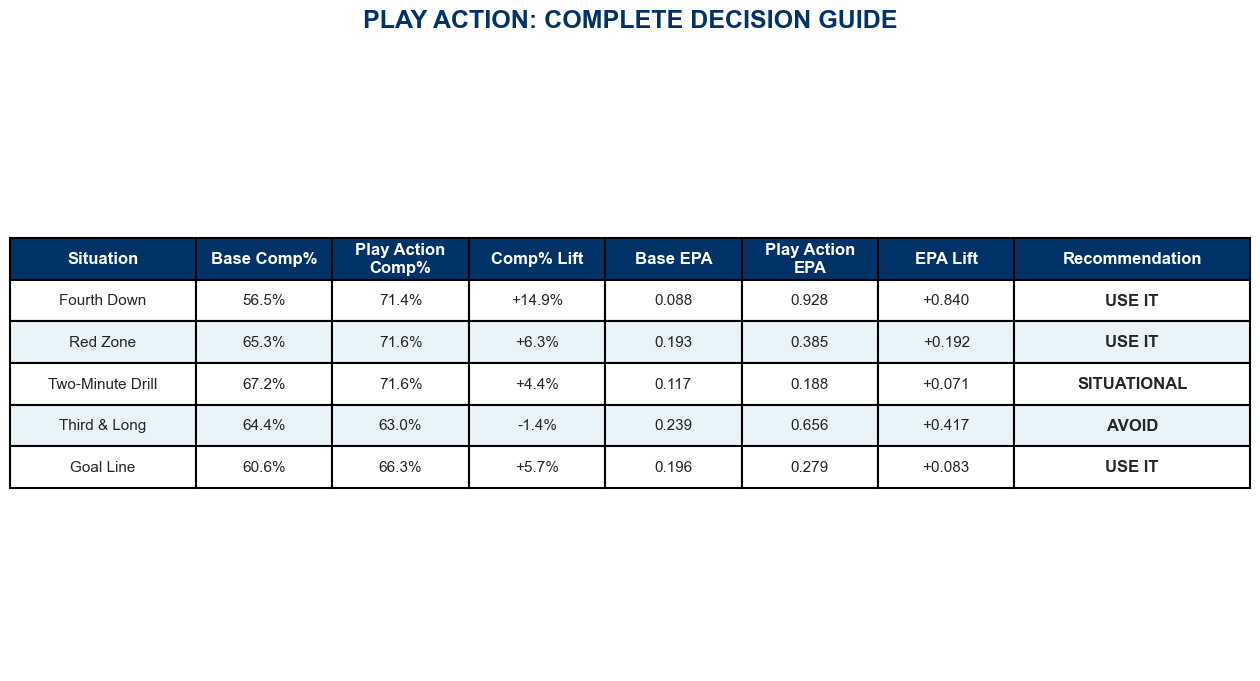

In [5]:
# DETAILED PLAY ACTION COMPARISON TABLE
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

# Prepare comparison data
comparison_data = []
for _, row in play_action.iterrows():
    situation = row['situation']
    
    comparison_data.append([
        situation,
        f"{row['without_pa_comp_rate']:.1f}%",
        f"{row['with_pa_comp_rate']:.1f}%",
        f"{row['comp_rate_improvement']:+.1f}%",
        f"{row['without_pa_epa']:.3f}",
        f"{row['with_pa_epa']:.3f}",
        f"{row['epa_improvement']:+.3f}",
        'USE IT' if row['comp_rate_improvement'] > 5 else ('SITUATIONAL' if row['comp_rate_improvement'] > 0 else 'AVOID')
    ])

columns = ['Situation', 'Base Comp%', 'Play Action\nComp%', 'Comp% Lift', 
           'Base EPA', 'Play Action\nEPA', 'EPA Lift', 'Recommendation']

# Create table
table = ax.table(cellText=comparison_data, colLabels=columns, 
                 cellLoc='center', loc='center',
                 colWidths=[0.15, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.19])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Header styling
for i in range(len(columns)):
    cell = table[(0, i)]
    cell.set_facecolor(NFL_BLUE)
    cell.set_text_props(weight='bold', color='white', fontsize=12)

# Row styling with alternating colors
for i in range(1, len(comparison_data) + 1):
    for j in range(len(columns)):
        cell = table[(i, j)]
        if i % 2 == 0:
            cell.set_facecolor('#E8F4F8')
        else:
            cell.set_facecolor('white')
        
        # Bold the recommendation column
        if j == 7:
            cell.set_text_props(weight='bold', fontsize=12)

plt.title('PLAY ACTION: COMPLETE DECISION GUIDE', 
          fontsize=18, weight='bold', pad=20, color=NFL_BLUE)

plt.savefig(dir/ 'play_action_decision_guide.png', dpi=300, bbox_inches='tight')
print('✅ Play Action Decision Guide saved')
plt.show()

---

## 📊 SIDELINE QUICK REFERENCE

### 🔴 AVOID THESE COMBINATIONS:

| Situation | Coverage | Comp % | Why to Avoid |
|-----------|----------|--------|--------------|
| Fourth Down | Cover 2 Man | 47.1% | Worst 4th down matchup |
| Two-Minute Drill | Cover 2 Man | 50.0% | Second worst - tight windows |
| Fourth Down | Cover 4 Zone | 52.3% | Deep safeties limit options |
| Two-Minute Drill | Cover 1 Man | 56.2% | Physical coverage disrupts timing |

### 🟢 ATTACK THESE COMBINATIONS:

| Situation | Coverage | Comp % | Why to Attack |
|-----------|----------|--------|---------------|
| Goal Line | Cover 4 Zone | 76.5% | Best overall matchup |
| Two-Minute Drill | Cover 2 Zone | 75.8% | Huge seam vulnerabilities |
| Red Zone | Cover 2 Zone | 74.6% | Zone drops create windows |
| Red Zone | Cover 6 Zone | 73.3% | Quarter-quarter-half beatable |
| 3rd & Long | Cover 2 Zone | 73.6% | Predictable zone drops |

### 🎭 PLAY ACTION CHEAT CODES:

| Situation | Comp % Boost | EPA Boost | Call It? |
|-----------|--------------|-----------|----------|
| Fourth Down | **+14.9%** | **+0.840** | ✅ ALWAYS |
| Red Zone | +6.3% | +0.192 | ✅ YES |
| Goal Line | +5.7% | +0.083 | ✅ YES |
| Two-Minute Drill | +4.4% | +0.071 | ⚠️ SITUATIONAL |
| 3rd & Long | -1.4% | +0.417 | ⚠️ BIG PLAY ONLY |